[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2021 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

WIP...
The project is currently under heavy development while adding new material for the summer semester 2021

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 5 Magnitude Bode Plot Approximation for LTI System Prototypes

### References:

* Norbert Fliege (1991): "*Systemtheorie*", Teubner, Stuttgart (GER), cf. chapter 4.3.5

* Alan V. Oppenheim, Alan S. Willsky with S. Hamid Nawab (1997): "*Signals & Systems*", Prentice Hall, Upper Saddle River NJ (USA), 2nd ed., cf. chapter 6

* Bernd Girod, Rudolf Rabenstein, Alexander Stenger (2001): "*Signals and Systems*", Wiley, Chichester (UK), cf. chapter 10

* Bernd Girod, Rudolf Rabenstein, Alexander Stenger (2005/2007): "*Einführung in die Systemtheorie*", Teubner, Wiesbaden (GER), 3rd/4th ed., cf. chapter 10

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
decades = 2  # plot number of decades left and right from cut frequency

## Single, Real Zero

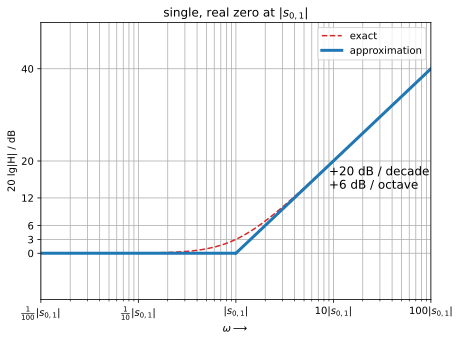

In [2]:
sz = -1
w = np.arange(np.abs(sz)/10**decades, np.abs(sz)*10**decades, 0.05)
s = 1j*w
H = +20*np.log10(np.abs(s/sz-1))
wconst = w[np.abs(s) < np.abs(sz)]
Hconst = 0*wconst
wslope = (np.abs(sz), w[-1])
Hslope = (0, +20*decades)

plt.figure(figsize=(7, 5))
plt.semilogx(w, H, '--', color='C3', label='exact')
plt.semilogx(wconst, Hconst, 'C0', label='approximation', lw=3)
plt.semilogx(wslope, Hslope, 'C0', lw=3)

plt.xlim(w[0], w[-1])
plt.ylim(-10, decades*20+10)

plt.xticks((1e-2, 1e-1, 1e0, 1e1, 1e2),
           [r'$\frac{1}{100}|s_{0,1}|$',
            r'$\frac{1}{10}|s_{0,1}|$',
           r'$|s_{0,1}|$',
            r'$10|s_{0,1}|$',
            r'$100|s_{0,1}|$'])
plt.yticks((0, 3, 6, 12, 20, 40))
plt.text(9, 14, '+20 dB / decade\n+6 dB / octave', fontsize=12)
plt.xlabel(r'$\omega \longrightarrow$')
plt.ylabel('20 lg|H| / dB')
plt.title(r'single, real zero at $|s_{0,1}|$')

plt.legend()
plt.grid(True, which='both')

plt.savefig('fig_bode_mag_single_zero.pdf')

## Single, Real Pole

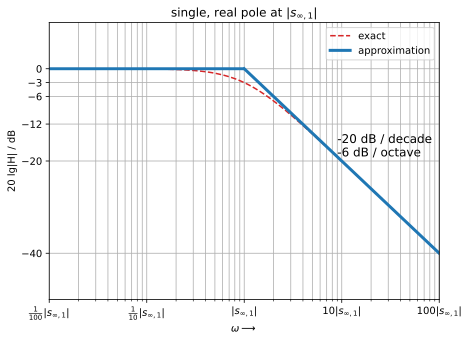

In [3]:
sp = -1
w = np.arange(np.abs(sp)/10**decades, np.abs(sp)*10**decades, 0.05)
s = 1j*w
H = -20*np.log10(np.abs(s/sp-1))
wconst = w[np.abs(s) < np.abs(sp)]
Hconst = 0*wconst
wslope = (np.abs(sp), w[-1])
Hslope = (0, -20*decades)

plt.figure(figsize=(7, 5))
plt.semilogx(w, H, '--', color='C3', label='exact')
plt.semilogx(wconst, Hconst, 'C0', label='approximation', lw=3)
plt.semilogx(wslope, Hslope, 'C0', lw=3)

plt.xlim(w[0], w[-1])
plt.ylim(-decades*20-10, 10)

plt.xticks((1e-2, 1e-1, 1e0, 1e1, 1e2),
           [r'$\frac{1}{100}|s_{\infty,1}|$',
            r'$\frac{1}{10}|s_{\infty,1}|$',
           r'$|s_{\infty,1}|$',
            r'$10|s_{\infty,1}|$',
            r'$100|s_{\infty,1}|$'])
plt.yticks((-40, -20, -12, -6, -3, 0))
plt.text(9, -19, '-20 dB / decade\n-6 dB / octave', fontsize=12)
plt.xlabel(r'$\omega \longrightarrow$')
plt.ylabel('20 lg|H| / dB')
plt.title(r'single, real pole at $|s_{\infty,1}|$')

plt.legend()
plt.grid(True, which='both')

plt.savefig('fig_bode_mag_single_pole.pdf')

## Complex Conjugate Zero Pair

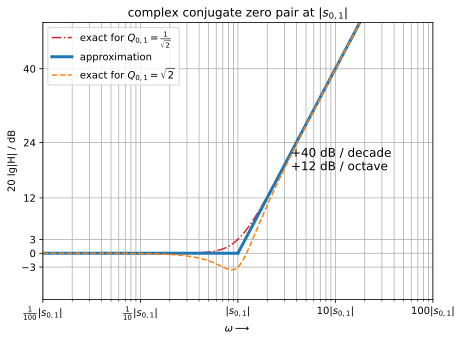

In [4]:
sz = -1/np.sqrt(2) - 1j*1/np.sqrt(2)
w = np.arange(np.abs(sz)/10**decades, np.abs(sz)*10**decades, 0.05)
s = 1j*w

Q = 1/np.sqrt(2)
HQ05 = s**2/np.abs(sz)**2 + s/np.abs(sz)/Q + 1
Q = np.sqrt(2)
HQ2 = s**2/np.abs(sz)**2 + s/np.abs(sz)/Q + 1

HQ05 = +20*np.log10(np.abs(HQ05))
HQ2 = +20*np.log10(np.abs(HQ2))

wconst = w[np.abs(s) < np.abs(sz)]
Hconst = 0*wconst
wslope = (np.abs(sz), w[-1])
Hslope = (0, +40*decades)

plt.figure(figsize=(7, 5))
plt.semilogx(w, HQ05, '-.', color='C3',
             label=r'exact for $Q_{0,1}=\frac{1}{\sqrt{2}}$')
plt.semilogx(wconst, Hconst, 'C0', label='approximation', lw=3)
plt.semilogx(wslope, Hslope, 'C0', lw=3)
plt.semilogx(w, HQ2, '--', color='C1', label=r'exact for $Q_{0,1}=\sqrt{2}$')


plt.xlim(w[0], w[-1])
plt.ylim(-10, decades*20+10)

plt.xticks((1e-2, 1e-1, 1e0, 1e1, 1e2),
           [r'$\frac{1}{100}|s_{0,1}|$',
            r'$\frac{1}{10}|s_{0,1}|$',
           r'$|s_{0,1}|$',
            r'$10|s_{0,1}|$',
            r'$100|s_{0,1}|$'])
plt.yticks((-3, 0, 3, 12, 24, 40))
plt.text(3.5, 18, '+40 dB / decade\n+12 dB / octave', fontsize=12)
plt.xlabel(r'$\omega \longrightarrow$')
plt.ylabel('20 lg|H| / dB')
plt.title(r'complex conjugate zero pair at $|s_{0,1}|$')

plt.legend()
plt.grid(True, which='both')
plt.savefig('fig_bode_mag_conj_zeros.pdf')

## Complex Conjugate Pole Pair

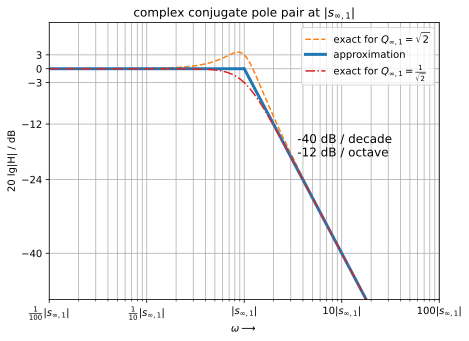

In [5]:
sp = -1/np.sqrt(2) - 1j*1/np.sqrt(2)
w = np.arange(np.abs(sp)/10**decades, np.abs(sp)*10**decades, 0.05)
s = 1j*w

Q = 1/np.sqrt(2)
HQ05 = s**2/np.abs(sp)**2 + s/np.abs(sp)/Q + 1
Q = np.sqrt(2)
HQ2 = s**2/np.abs(sp)**2 + s/np.abs(sp)/Q + 1

HQ05 = -20*np.log10(np.abs(HQ05))
HQ2 = -20*np.log10(np.abs(HQ2))

wconst = w[np.abs(s) < np.abs(sp)]
Hconst = 0*wconst
wslope = (np.abs(sp), w[-1])
Hslope = (0, -40*decades)

plt.figure(figsize=(7, 5))
plt.semilogx(w, HQ2, '--', color='C1',
             label=r'exact for $Q_{\infty,1}=\sqrt{2}$')
plt.semilogx(wconst, Hconst, 'C0', label='approximation', lw=3)
plt.semilogx(wslope, Hslope, 'C0', lw=3)
plt.semilogx(w, HQ05, '-.', color='C3',
             label=r'exact for $Q_{\infty,1}=\frac{1}{\sqrt{2}}$')


plt.xlim(w[0], w[-1])
plt.ylim(-decades*20-10, 10)

plt.xticks((1e-2, 1e-1, 1e0, 1e1, 1e2),
           [r'$\frac{1}{100}|s_{\infty,1}|$',
            r'$\frac{1}{10}|s_{\infty,1}|$',
           r'$|s_{\infty,1}|$',
            r'$10|s_{\infty,1}|$',
            r'$100|s_{\infty,1}|$'])
plt.yticks((-40, -24, -12, -3, 0, 3))
plt.text(3.5, -19, '-40 dB / decade\n-12 dB / octave', fontsize=12)
plt.xlabel(r'$\omega \longrightarrow$')
plt.ylabel('20 lg|H| / dB')
plt.title(r'complex conjugate pole pair at $|s_{\infty,1}|$')

plt.legend()
plt.grid(True, which='both')
plt.savefig('fig_bode_mag_conj_poles.pdf')

## Constant Gain

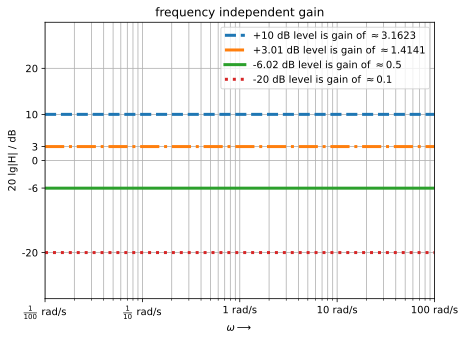

In [6]:
sp = -1
w = np.arange(np.abs(sp)/10**decades, np.abs(sp)*10**decades, 0.05)
s = 1j*w

plt.figure(figsize=(7, 5))
H0 = 10
H = H0 + 20*np.log10(np.abs(s)*0+1)
plt.semilogx(w, H, '--', color='C0', lw=3,
             label=r'+10 dB level is gain of $\approx 3.1623$')

H0 = +3.01
H = H0 + 20*np.log10(np.abs(s)*0+1)
plt.semilogx(w, H, '-.', color='C1', lw=3,
             label=r'+3.01 dB level is gain of $\approx 1.4141$')

H0 = -6.02
H = H0 + 20*np.log10(np.abs(s)*0+1)
plt.semilogx(w, H, color='C2', lw=3,
             label=r'-6.02 dB level is gain of $\approx 0.5$')

H0 = -20
H = H0 + 20*np.log10(np.abs(s)*0+1)
plt.semilogx(w, H, ':', color='C3', lw=3,
             label=r'-20 dB level is gain of $\approx 0.1$')

plt.xlim(w[0], w[-1])
plt.ylim(-30, 30)

plt.xticks((1e-2, 1e-1, 1e0, 1e1, 1e2),
           [r'$\frac{1}{100}$ rad/s',
            r'$\frac{1}{10}$ rad/s',
           r'$1$ rad/s',
            r'$10$ rad/s',
            r'$100$ rad/s'])
plt.yticks((-20, -6, 0, 3, 10, 20), ['-20', '-6', '0', '3', '10', '20'])

plt.xlabel(r'$\omega \longrightarrow$')
plt.ylabel('20 lg|H| / dB')
plt.title(r'frequency independent gain')

plt.legend()
plt.grid(True, which='both')
plt.savefig('fig_bode_mag_gain.pdf')

## Poles and Zeros in Origin of s-Plane 

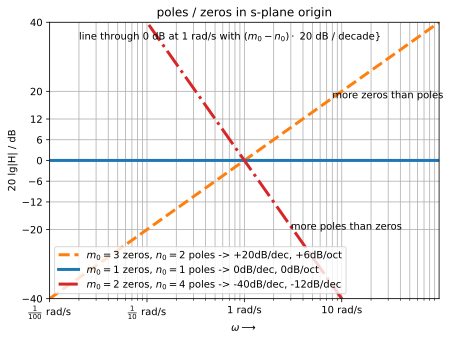

In [7]:
w = np.arange(1/10**decades, 1*10**decades, 0.05)
s = 1j*w

plt.figure(figsize=(7, 5))
m0 = 3  # zeros in origin
n0 = 2  # poles in origin
H = (m0-n0) * 20*np.log10(np.abs(s))
plt.semilogx(w, H, '--', color='C1', lw=3,
             label=r'$m_0=3$ zeros, $n_0=2$ poles -> +20dB/dec, +6dB/oct')

m0 = 1  # zeros in origin
n0 = 1  # poles in origin
H = (m0-n0) * 20*np.log10(np.abs(s))
plt.semilogx(w, H, color='C0', lw=3,
             label=r'$m_0=1$ zeros, $n_0=1$ poles -> 0dB/dec, 0dB/oct')

m0 = 2  # zeros in origin
n0 = 4  # poles in origin
H = (m0-n0) * 20*np.log10(np.abs(s))
plt.semilogx(w, H, '-.', color='C3', lw=3,
             label=r'$m_0=2$ zeros, $n_0=4$ poles -> -40dB/dec, -12dB/dec')

plt.xticks((1e-2, 1e-1, 1e0, 1e1, 1e2),
           [r'$\frac{1}{100}$ rad/s',
            r'$\frac{1}{10}$ rad/s',
           r'$1$ rad/s',
            r'$10$ rad/s',
            r'$100$ rad/s'])
plt.yticks((-40, -20, -12, -6, 0, 6, 12, 20, 40))
plt.xlim(w[0], w[-1])
plt.ylim(-40, 40)
plt.xlabel(r'$\omega \longrightarrow$')
plt.ylabel('20 lg|H| / dB')
plt.title(r'poles / zeros in s-plane origin')
plt.text(0.02, 35, r'line through 0 dB at 1 rad/s with ($m_0-n_0) \cdot$ 20 dB / decade}')
plt.text(8, +18, r'more zeros than poles')
plt.text(3, -20, r'more poles than zeros')
plt.legend(loc='lower left')
plt.grid(True, which='both')
plt.savefig('fig_bode_mag_origin_zeros_poles.pdf')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``main file, github URL, commit number and/or version tag, year``.